In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("../data/raw/AI_Resume_Screening.csv")

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Recruiter Decision'] = le.fit_transform(df['Recruiter Decision'])
X = df[
    [
        'Experience (Years)',
        'Projects Count',
        'AI Score (0-100)',
        'Salary Expectation ($)'
    ]
]

y = df['Recruiter Decision']

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       154
           1       1.00      1.00      1.00        46

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [3]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                  Feature  Importance
2        AI Score (0-100)    0.737740
0      Experience (Years)    0.195913
1          Projects Count    0.060618
3  Salary Expectation ($)    0.005729


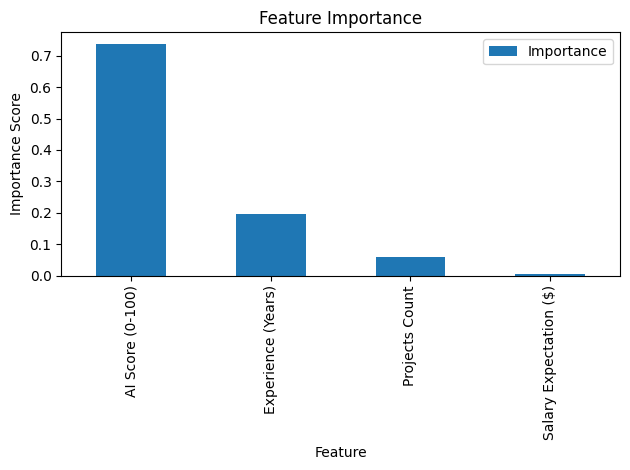

In [4]:
import matplotlib.pyplot as plt

feature_importance.plot(
    x='Feature',
    y='Importance',
    kind='bar'
)

plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()